In [1]:
print("0.)")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Kurt Russel S. Belnas"
student_id = "TUPM-25-0291"  # Replace with your actual ID

id_num = int(student_id[-3:])

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

# ✅ LOAD DATA (THIS WAS MISSING)
df = pd.read_csv(r"C:\Users\Kurt Russel\OneDrive\Documents\Lab7_DataVisualization_Belnas\spotify_top_1000_tracks.csv")

# (optional safety check)
df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce')
df = df.dropna(subset=['duration_min'])

0.)


1.)


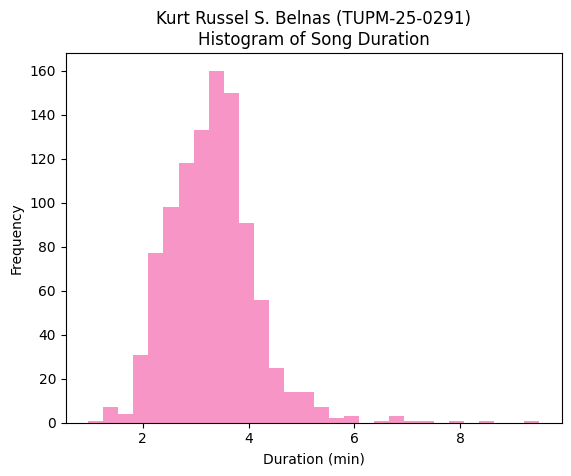

In [2]:
print("1.)")

df['duration_min'].plot(
    kind='hist',
    bins=30,
    color=color1,
    alpha=0.7
)

plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')

plt.show()

2.)
Index(['track_name', 'artist', 'album', 'release_date', 'popularity',
       'spotify_url', 'id', 'duration_min'],
      dtype='str')


C:\Users\Kurt Russel\AppData\Local\Temp\ipykernel_18592\1546857452.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


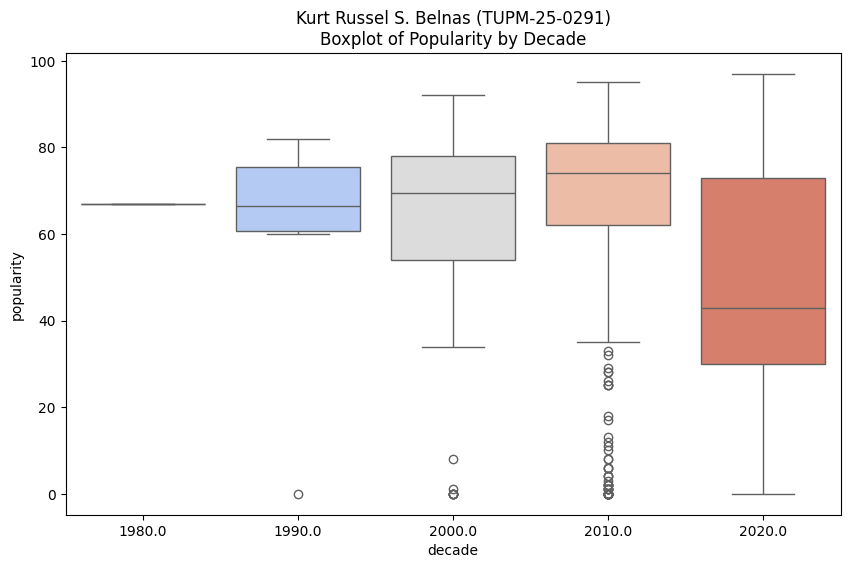

In [3]:
print("2.)")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(df.columns)  # IMPORTANT: check actual columns

# If release_date exists
if 'release_date' in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['year'] = df['release_date'].dt.year

# Now safely create decade IF year exists
if 'year' in df.columns:
    df['decade'] = (df['year'] // 10) * 10
else:
    raise ValueError("Dataset has no usable year column (check df.columns)")

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='decade',
    y='popularity',
    palette='coolwarm'
)

plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.show()

3.)


C:\Users\Kurt Russel\AppData\Local\Temp\ipykernel_18592\3817267116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


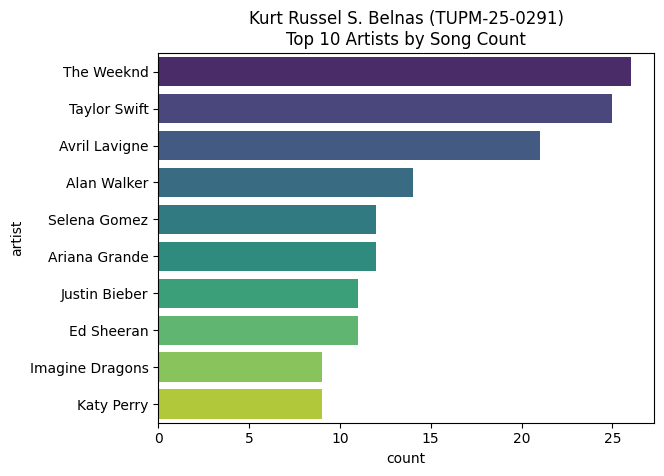

In [4]:
print("3.)")

sns.countplot(y='artist', data=df, 
order=df['artist'].value_counts().head(10).index, palette='viridis') 
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count") 
plt.show() 

4.)


C:\Users\Kurt Russel\AppData\Local\Temp\ipykernel_18592\1225120205.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


KeyboardInterrupt: 

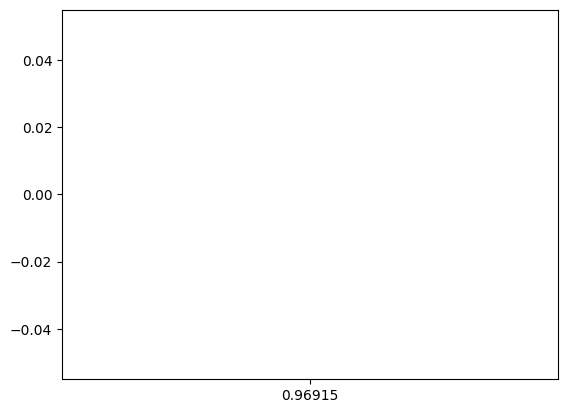

In [ ]:
print("4.)")

sns.violinplot(
    data=df,
    x='duration_min',
    y='decade',
    palette='coolwarm'
)

plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.show()

5.)


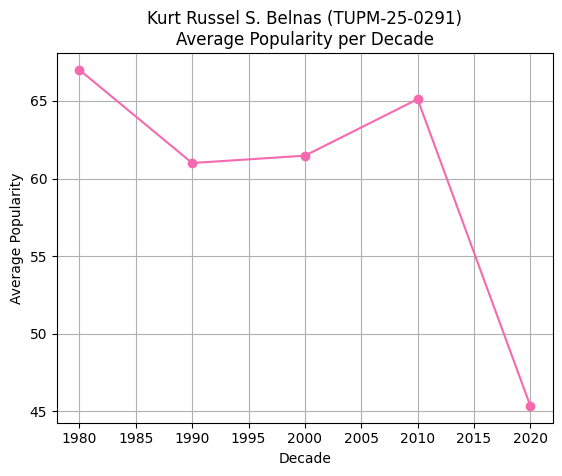

In [8]:
print("5.)")

avg_pop = df.groupby('decade')['popularity'].mean() 
avg_pop.plot(kind='line', color=color1, marker='o') 
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade") 
plt.xlabel('Decade') 
plt.ylabel('Average Popularity') 
plt.grid(True) 
plt.show() 

6.)


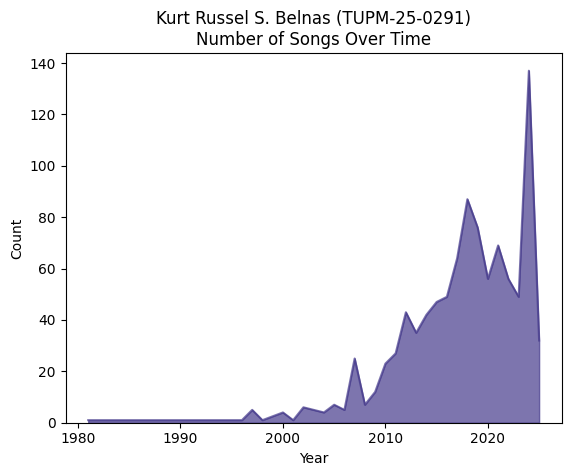

In [9]:
print("6.)")

df['release_year'] = pd.to_datetime(df['release_date'], 
errors='coerce').dt.year 
count_by_year = df['release_year'].value_counts().sort_index() 
count_by_year.plot(kind='area', color=color2, alpha=0.7) 
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time") 
plt.xlabel('Year') 
plt.ylabel('Count') 
plt.show() 

7.)


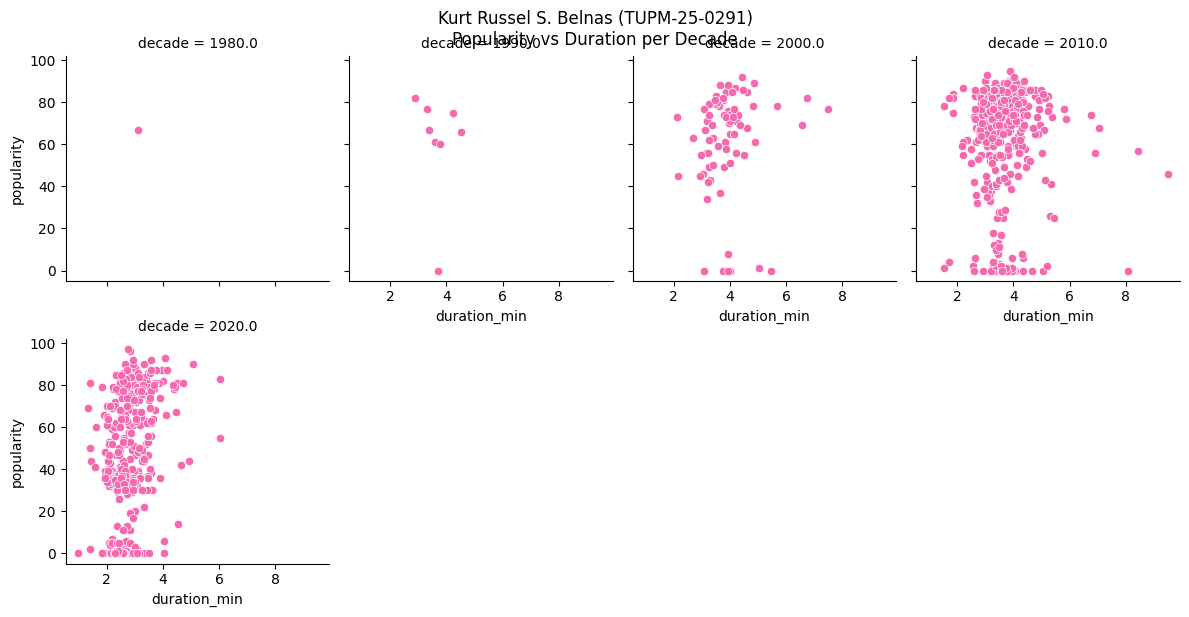

In [10]:
print("7.)")

g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3) 
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', 
color=color1) 
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02) 
plt.show() 

8.)


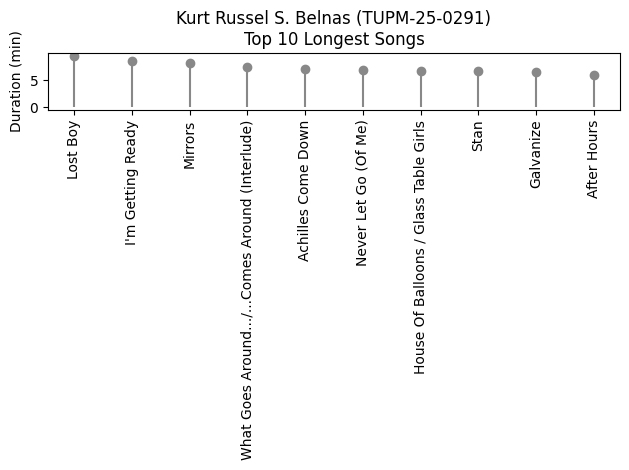

In [11]:
print("8.)")

longest = df.nlargest(10, 'duration_min') 
plt.stem(longest['track_name'], longest['duration_min'], 
linefmt='#888888', markerfmt='o', basefmt=" ") 
plt.xticks(rotation=90) 
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs") 
plt.ylabel('Duration (min)') 
plt.tight_layout() 
plt.show() 

9.)


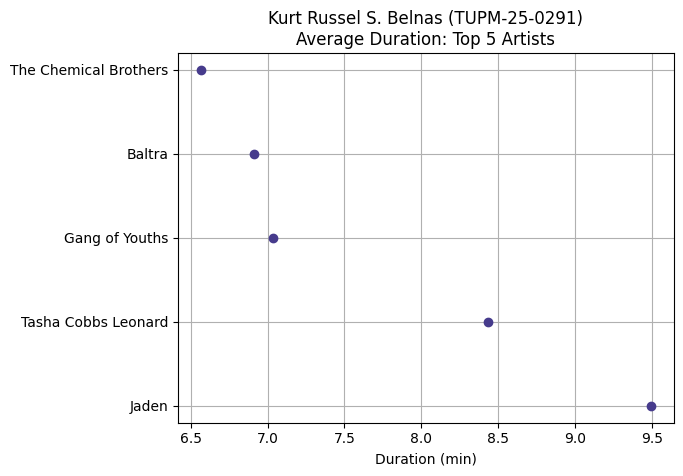

In [12]:
print("9.)")

avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5) 
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2) 
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists") 
plt.xlabel('Duration (min)') 
plt.grid(True) 
plt.show() 

10.)


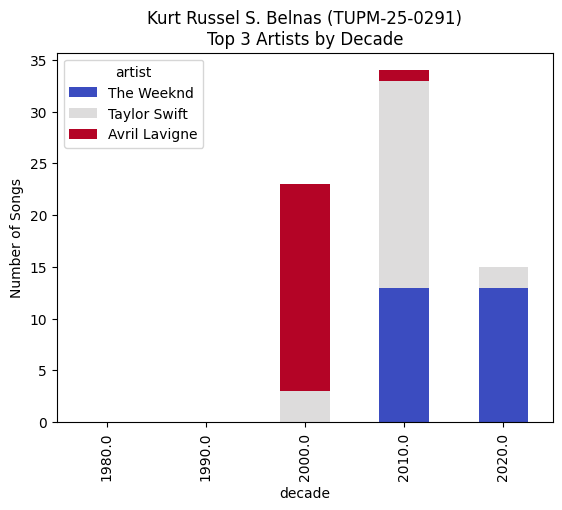

In [13]:
print("10.)")

crosstab = pd.crosstab(df['decade'], df['artist']) 
top3 = df['artist'].value_counts().head(3).index 
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm') 
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade") 
plt.ylabel('Number of Songs') 
plt.show() 

11.)


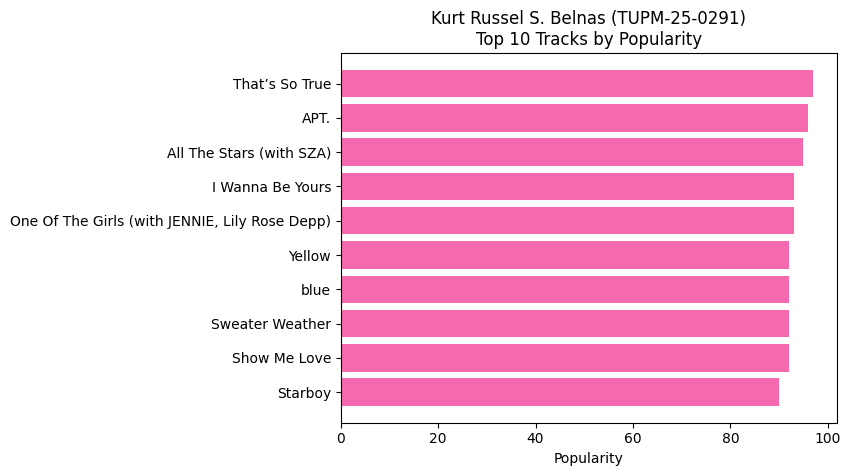

In [14]:
print("11.)")

top_tracks = df.nlargest(10, 'popularity') 
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1) 
plt.xlabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity") 
plt.gca().invert_yaxis() 
plt.show() 

12.)


C:\Users\Kurt Russel\AppData\Local\Temp\ipykernel_18592\2197154680.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
C:\Users\Kurt Russel\AppData\Local\Temp\ipykernel_18592\2197154680.py:4: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',


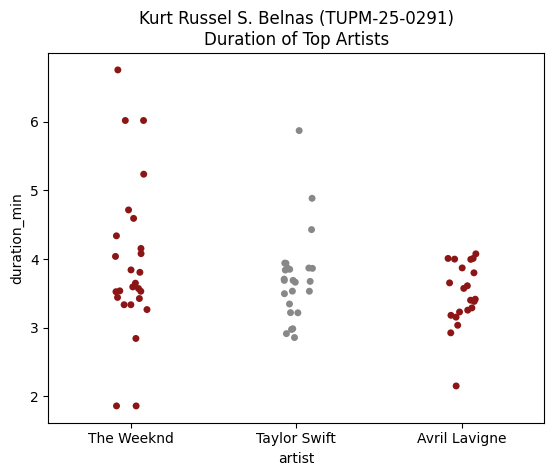

In [15]:
print("12.)")

top_artists = df['artist'].value_counts().head(3).index 
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', 
y='duration_min', palette=['#8C1515', '#888888']) 
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists") 
plt.show() 

13.)


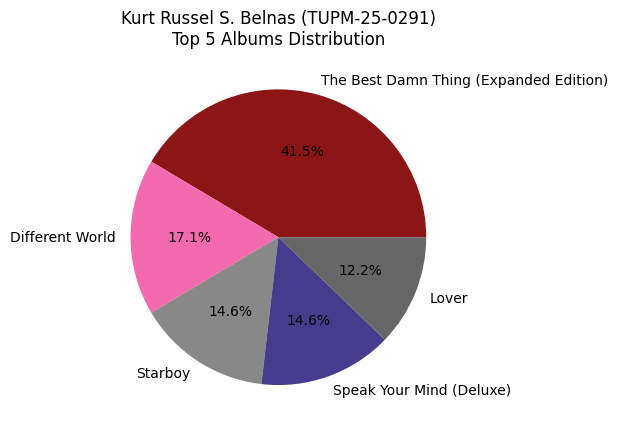

In [16]:
print("13.)")

top_albums = df['album'].value_counts().head(5) 
colors = ['#8C1515', color1, '#888888', color2, '#666666'] 
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', 
colors=colors) 
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution") 
plt.show() 

14.)


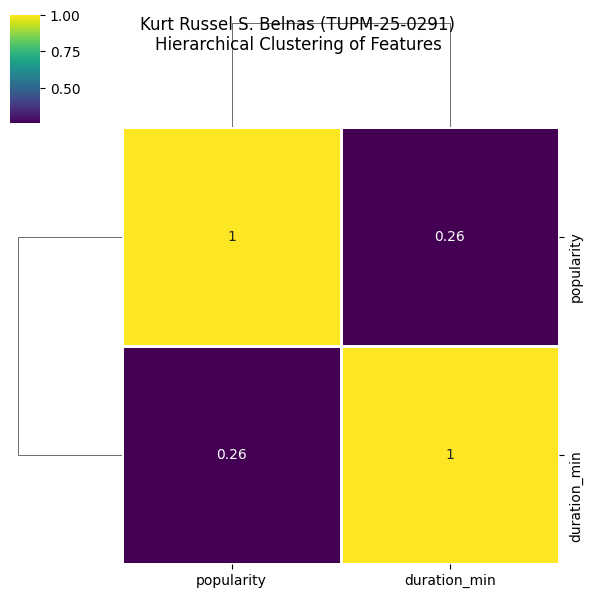

In [17]:
print("14.)")

numerical_cols = ['popularity', 'duration_min'] 
df_numeric = df[numerical_cols].dropna() 
sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis', 
linewidths=.75, figsize=(6, 6)) 
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features") 
plt.show()

15.)


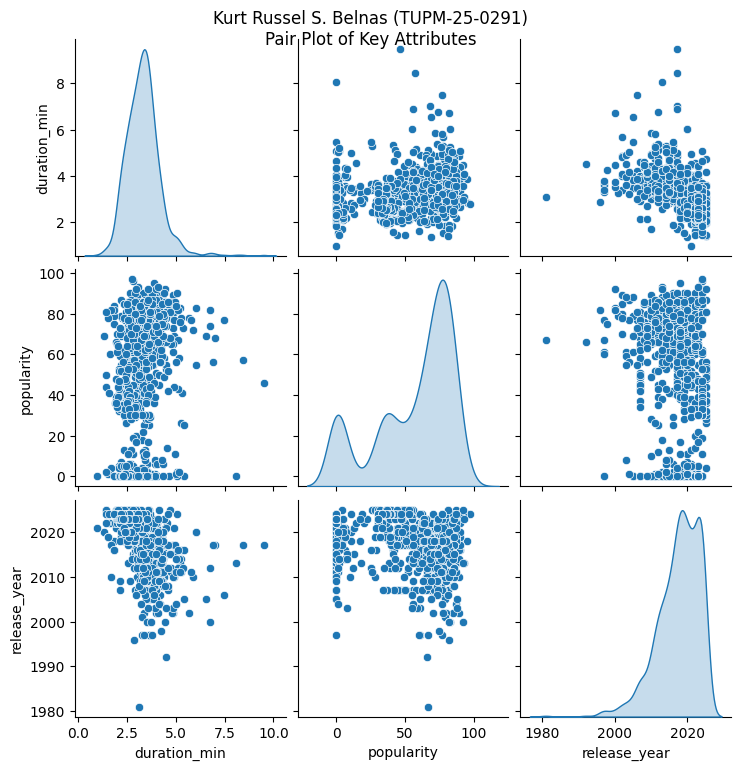

In [18]:
print("15.)")

sns.pairplot(df[['duration_min', 'popularity', 'release_year']], 
diag_kind='kde') 
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02) 
plt.show() 

16.)


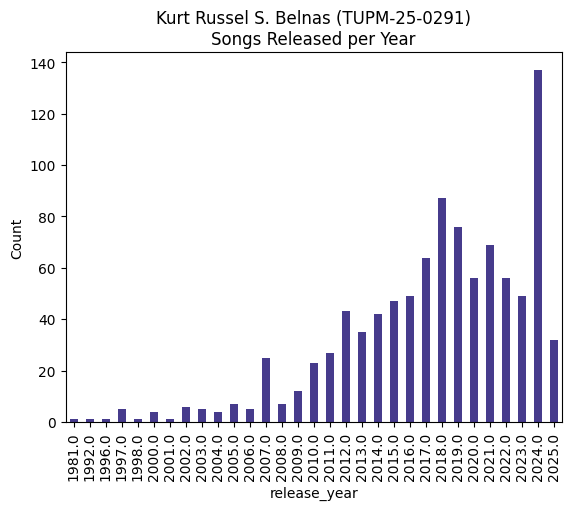

In [19]:
print("16.)")

df['release_year'].value_counts().sort_index().plot(kind='bar', 
color=color2) 
plt.title(f"{student_name} ({student_id})\nSongs Released per Year") 
plt.ylabel('Count') 
plt.show() 

17.)


C:\Users\Kurt Russel\AppData\Local\Temp\ipykernel_18592\2181194008.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity',


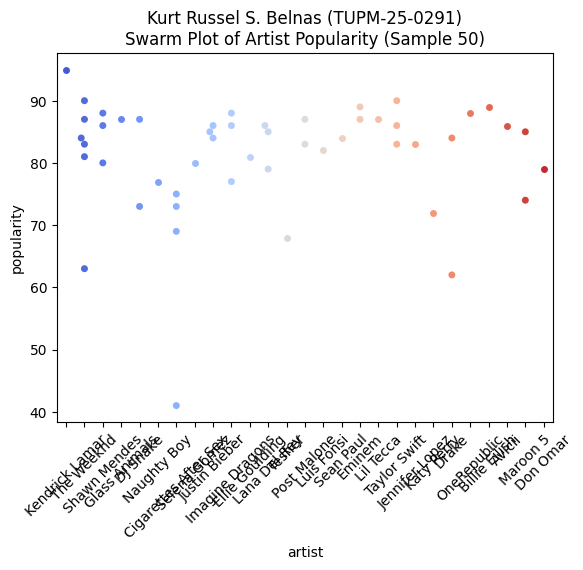

In [20]:
print("17.)")

sns.swarmplot(data=df.head(50), x='artist', y='popularity', 
palette='coolwarm') 
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)") 
plt.xticks(rotation=45) 
plt.show() 

18.)


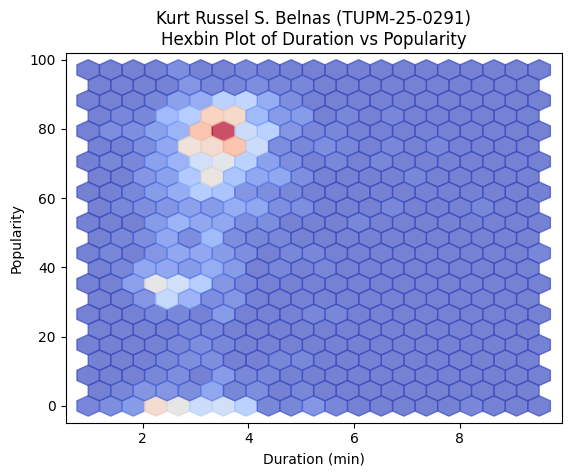

In [21]:
print("18.)")

plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, 
cmap='coolwarm', alpha=0.7) 
plt.xlabel('Duration (min)') 
plt.ylabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity") 
plt.show()

19.)


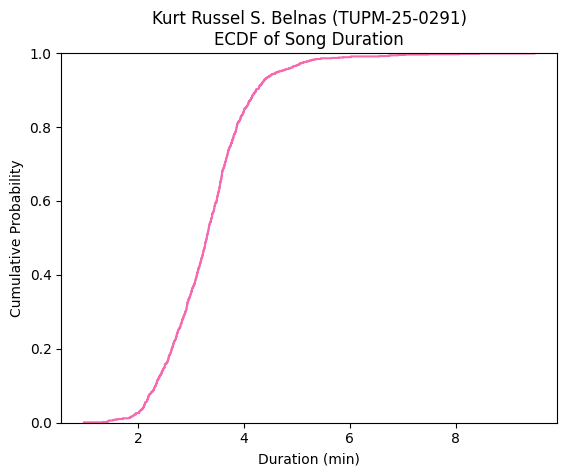

In [22]:
print("19.)")

sns.ecdfplot(data=df, x='duration_min', color=color1) 
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Cumulative Probability') 
plt.show() 

20.)


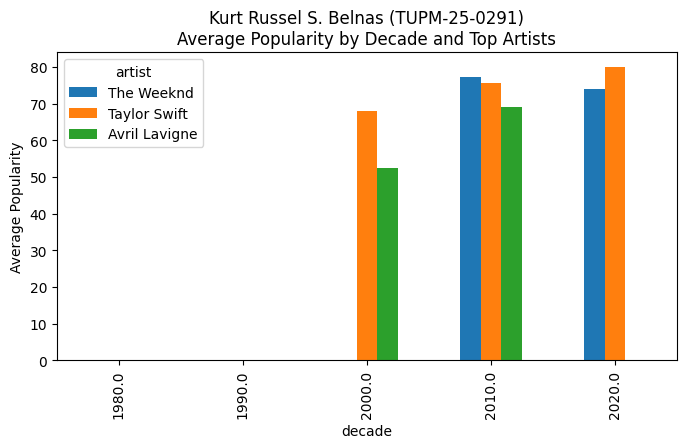

In [23]:
print("20.)")

avg_artist_decade = df.groupby(['decade', 
'artist'])['popularity'].mean().unstack().fillna(0) 
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4)) 
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists") 
plt.ylabel('Average Popularity') 
plt.show() 